In [7]:
from quantum_qr.qrng import generate_quantum_random_bits

In [8]:
bits = generate_quantum_random_bits(128)

# Convert list → binary string
binary_nonce = "".join(map(str, bits))

# Convert binary → hex (32 hex chars for 128 bits)
hex_nonce = hex(int(binary_nonce, 2))[2:].zfill(32)

print("🔐 Binary Nonce (128-bit):")
print(binary_nonce)

print("\n🔐 Hex Nonce (32 chars):")
print(hex_nonce)

Counts: {'01001000011110110011110111100011101100110000100011101101111101100010011111111000101011001011010010101100011111101110010101010110': 1}

128 Random Bits:
[0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0]
🔐 Binary Nonce (128-bit):
01101010101001110111111000110101001011010011010100011111111001000110111110110111000100001100110111000111101111001101111000010010

🔐 Hex Nonce (32 chars):
6aa77e352d351fe46fb710cdc7bcde12


In [9]:
import os

os.makedirs("../data", exist_ok=True)

with open("../data/sample_nonce.txt", "w") as f:
    f.write("Binary Nonce:\n")
    f.write(binary_nonce + "\n\n")
    f.write("Hex Nonce:\n")
    f.write(hex_nonce)

print("\n✅ Saved to data/sample_nonce.txt")


✅ Saved to data/sample_nonce.txt


In [10]:
all_bits = []

num_bits = 10000
batch_size = 128

while len(all_bits) < num_bits:
    bits = generate_quantum_random_bits(batch_size)
    all_bits.extend(bits)

# Trim extra bits
all_bits = all_bits[:num_bits]

print("Total bits generated:", len(all_bits))

Counts: {'00111010001010101100011010111100101110000100111001110100010010010011011101001100001100100111110101101010011101110100100000110111': 1}

128 Random Bits:
[1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0]
Counts: {'00000100010001111100100000000100010110100001111001011011100010110111110110000100101101100011101101101111010010100100011111100100': 1}

128 Random Bits:
[0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0,

In [11]:
zeros = all_bits.count(0)
ones = all_bits.count(1)

print("Zeros:", zeros)
print("Ones:", ones)

Zeros: 5020
Ones: 4980


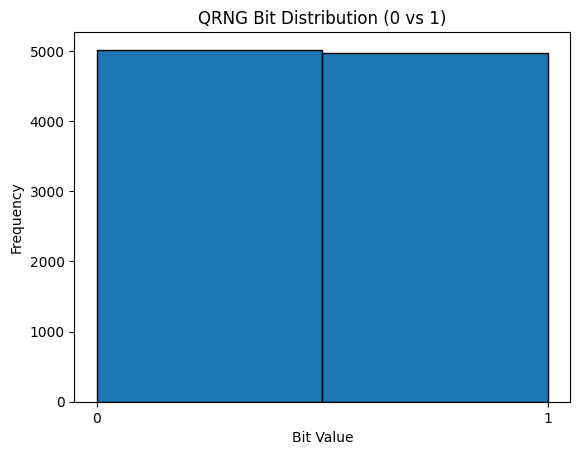

In [12]:
import matplotlib.pyplot as plt

plt.hist(all_bits, bins=2, edgecolor='black')
plt.xticks([0, 1])
plt.title("QRNG Bit Distribution (0 vs 1)")
plt.xlabel("Bit Value")
plt.ylabel("Frequency")
plt.show()

In [13]:
from scipy.stats import chisquare

observed = [zeros, ones]
expected = [num_bits/2, num_bits/2]

chi_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print("Chi-square statistic:", chi_stat)
print("p-value:", p_value)

Chi-square statistic: 0.16
p-value: 0.6891565167793516


### compare Psudo random number vs Quantum Random Number

In [14]:
import random

num_bits = 10000

pseudo_bits = [random.getrandbits(1) for _ in range(num_bits)]

print("Generated pseudo-random bits:", len(pseudo_bits))

Generated pseudo-random bits: 10000


In [15]:
pseudo_zeros = pseudo_bits.count(0)
pseudo_ones = pseudo_bits.count(1)

print("Pseudo Zeros:", pseudo_zeros)
print("Pseudo Ones:", pseudo_ones)

Pseudo Zeros: 4999
Pseudo Ones: 5001


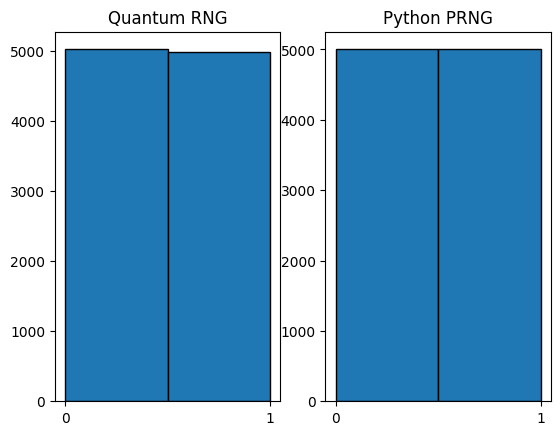

In [16]:
import matplotlib.pyplot as plt

plt.figure()

plt.subplot(1, 2, 1)
plt.hist(all_bits, bins=2, edgecolor='black')
plt.xticks([0, 1])
plt.title("Quantum RNG")

plt.subplot(1, 2, 2)
plt.hist(pseudo_bits, bins=2, edgecolor='black')
plt.xticks([0, 1])
plt.title("Python PRNG")

plt.show()

In [17]:
from scipy.stats import chisquare

pseudo_observed = [pseudo_zeros, pseudo_ones]
expected = [num_bits/2, num_bits/2]

chi_stat_pseudo, p_value_pseudo = chisquare(
    f_obs=pseudo_observed,
    f_exp=expected
)

print("Chi-square (PRNG):", chi_stat_pseudo)
print("p-value (PRNG):", p_value_pseudo)

Chi-square (PRNG): 0.0004
p-value (PRNG): 0.984043372566196


In [18]:
print("=== COMPARISON ===")
print("QRNG Zeros:", zeros, "Ones:", ones)
print("PRNG Zeros:", pseudo_zeros, "Ones:", pseudo_ones)

=== COMPARISON ===
QRNG Zeros: 5020 Ones: 4980
PRNG Zeros: 4999 Ones: 5001
